In [9]:
import pandas as pd
df=pd.read_csv(r"C:\Users\Acer\Desktop\Data_Science_Projects\Tele_Cust_ChurnClassification\data\drug200.csv")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


In [10]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [11]:
X=df[['Age','Sex','BP','Cholesterol','Na_to_K']].copy()
y=df['Drug']

In [12]:
#Encode Categorical Features
from sklearn.preprocessing import LabelEncoder
le_sex=LabelEncoder()
le_bp=LabelEncoder()
le_chol=LabelEncoder()

X['Sex']=le_sex.fit_transform(X['Sex'])
X['BP']=le_bp.fit_transform(X['BP'])
X['Cholesterol']=le_chol.fit_transform(X['Cholesterol'])

In [13]:
X.head()

,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0,0,0,25.355
1,47,1,1,0,13.093
2,47,1,1,0,10.114
3,28,0,2,0,7.798
4,61,0,1,0,18.043


In [14]:
#Train-test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [15]:
#Train Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
drugTree=DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)
drugTree.fit(X_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
from sklearn.metrics import accuracy_score
y_pred=drugTree.predict(X_test)
print("Decision Tree Accuracy : ",accuracy_score(y_test,y_pred))

Decision Tree Accuracy :  1.0


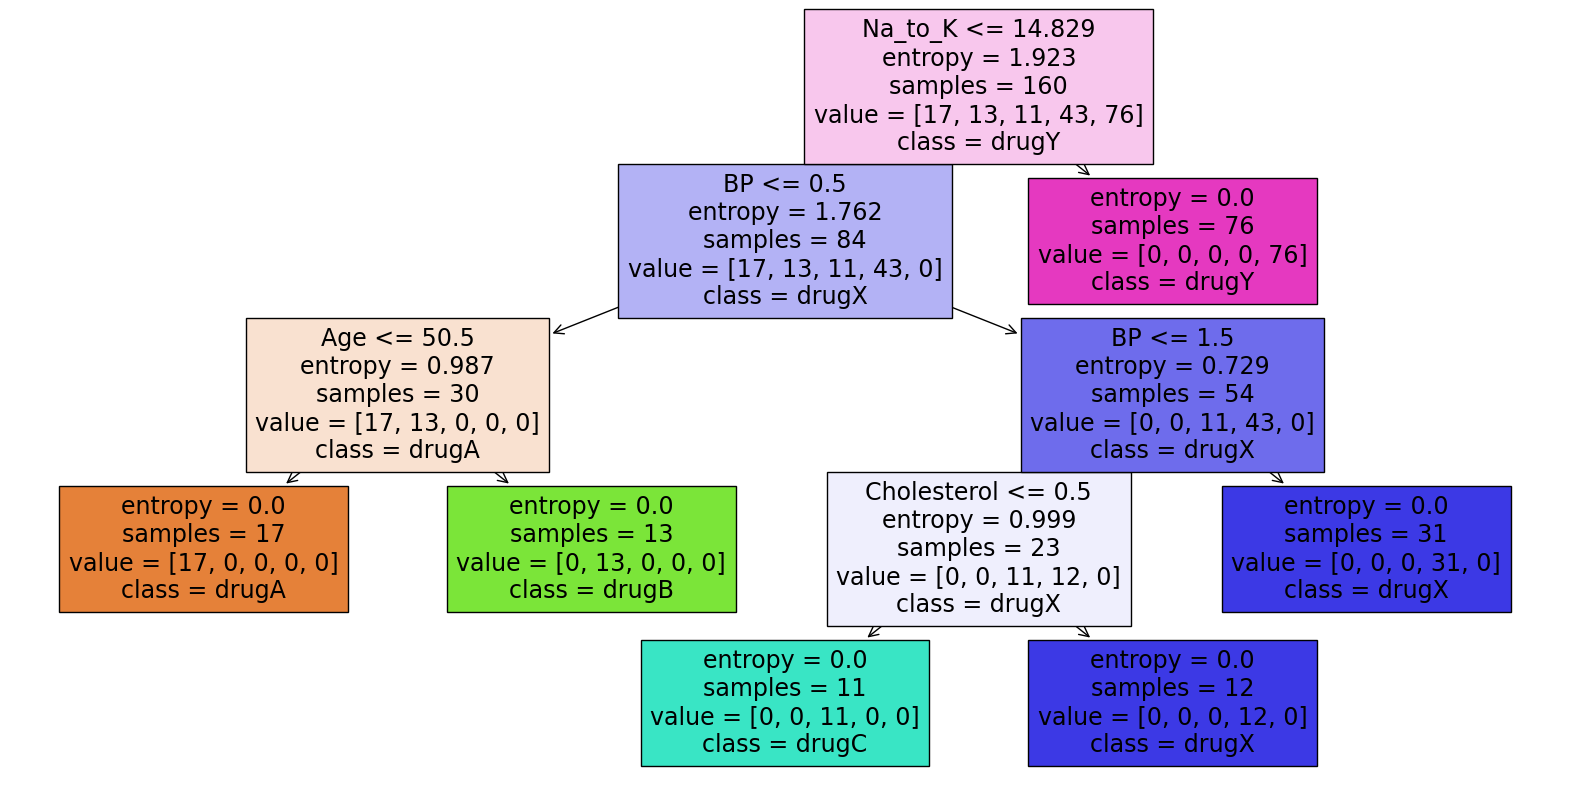

In [18]:
#visualize the Decision tree
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
plot_tree(
    drugTree,
    feature_names=X.columns,
    class_names=drugTree.classes_,
    filled=True
)
plt.show()

In [19]:
#Verify Feature Importance 
importance = pd.Series(
    drugTree.feature_importances_,
    index=X.columns).sort_values(ascending=False)

importance

Na_to_K        0.519065
BP             0.310040
Age            0.096247
Cholesterol    0.074649
Sex            0.000000
dtype: float64

# Entropy measures the impurity or randomness in a dataset.
Entropy-0 ----pure node.
Entropy-1 ------Evenly mixed.
Lower entropy = better classification

# Information Gain
IG measures the reduction in entropy after splitting data on an attribute.
Higher info gain=better attribute.

High entropy reduction = high information gain i.e high IG => low entropy.
